# Titulo: **2A. Reporte escrito. Experimentos y análisis de estructuras de datos.**

**Nombre**: Jovanna del Rocío Aguilar López

# Introducción

El estudio de estructuras de datos básicas, muestra cómo la representación interna de un conjunto dinámico influye directamente en el desempeño de las operaciones que se realizan sobre él. Aun cuando las operaciones sean conceptualmente simples, la forma en que los datos se almacenan y se recorren determina su costo en tiempo y memoria. Como se discute en Cormen et al. (2009), la representación de los conjuntos de datos mediante distintas estructuras influye directamente en el costo de las operaciones que se realizan sobre ellos.

Siguiendo esta idea, en este ejercicio se analiza un conjunto de datos representado como la tupla $(Q, X)$, comparando dos enfoques distintos para resolver el mismo problema y observando cómo la estructura elegida impacta en la eficiencia y escalabilidad del algoritmo.

El algoritmo **A1** construye explícitamente la matriz completa de productos punto y luego obtiene el máximo por fila. En cambio, el algoritmo **A2** evita construir esta matriz y calcula los productos punto de forma creciente, almacenando únicamente el mejor valor encontrado en cada caso.

A partir de esto se comparan ambos enfoques en términos de memoria y tiempo de ejecución para distintas combinaciones de $m$, $n$ y $d$, con el fin de analizar su comportamiento.


# Actividad

Dada la matriz de tamaño $d \times m$ y la matriz $X$ de tamaño $d \times n$, para cada vector columna $q \in Q$, encontrar el vector columna de $x \in X$, que maximiza su producto punto. Dicho de otra forma, el problema consiste en asociar cada $q$ con  $arg max\{q • x \mid x \in X\}$. Este será el problema de encontrar el producto punto máximo o **top-1**. Obtenga un arreglo de identificadores de columna como resultado (nns) y otro con el valor del producto punto máximo (dots) para cada columna en $Q$.


\begin{equation}
Q=\begin{pmatrix}
q_{1,1} & q_{1,2} & \cdots & q_{1,m}\\
q_{2,1} & q_{2,2} & \cdots & q_{2,m}\\
\vdots & \vdots & \ddots & \vdots\\
q_{d,1} & q_{d,2} & \cdots & q_{d,m}
\end{pmatrix}
\end{equation}

\begin{equation}
X=\begin{pmatrix}
x_{1,1} & x_{1,2} & \cdots & x_{1,n}\\
x_{2,1} & x_{2,2} & \cdots & x_{2,n}\\
\vdots & \vdots & \ddots & \vdots\\
x_{d,1} & x_{d,2} & \cdots & x_{d,n}
\end{pmatrix}
\end{equation}

a) Cree el algoritmo **A1** con operaciones matriciales explicitas.

In [47]:
using LinearAlgebra

#Definimos la función A1 
function A1(Q::Matrix{Float32}, X::Matrix{Float32})
#Definimos S y su tamaño
    S = transpose(Q)*X
    m,n = size(S)
#Definimos un vector para guardar indice
    nns = Vector{Int}(undef,m)
#Definimos un vector para guardar el valor máximo 
    dots = Vector{Float32}(undef, m)
#Recorre cada fila de S
    for j in 1:m
        maxpos = 1
        maxdot =S[j, 1]
#Recorre las demás  columnas buscando el máximo de la fila
        for i in 2:n
            v = S[j,i]
            if v > maxdot
                maxdot = v
                maxpos = i
            end
        end
#Guarda el índice y el valor máximo del producto   
        nns[j] = maxpos
        dots[j] = maxdot
    end
#Devuelve ambos resultados
    return nns, dots
end

A1 (generic function with 2 methods)

b) Adapte el algoritmo getmaxdot de las notas (Cap. 2) para el mismo lenguaje de tu implementación para resolver el mismo problema, llamemoslo **A2**.


In [50]:
using LinearAlgebra

# Definimos función mydot
function mydot(u, x)
    s = 0f0
#Recorre los índices para u y x
    for i in eachindex(u, x)
#Multiplicamos elemento a elemento y sumamos
        s += u[i] * x[i]
    end
    return s #Devuelve s
end

# Definimos getmaxdot, buscamos la columna de X que maximiza u·X[:,i]
@views function getmaxdot(u::AbstractVector, X::AbstractMatrix)
#Empezamos en la columna 1
  maxpos = 1
#Calula el producto punto entre u y la 1er columna de X
  maxdot = mydot(u, X[:, 1])
#Tamaño de la matriz X
   ncols = size(X,2)
#Recorre las columnas restantes
  for i in 2:ncols
#Calula el producto punto entre u y la columna i de X
    v = mydot(u, X[:, i])
# Vemos si el nuevo producto punto es mayor que el máximo guardado
    if v > maxdot
      maxpos = i #mejor columna
      maxdot = v #valor máximo
    end
  end

  return (maxpos, maxdot)
end

#Defimos A2 para el caso de dos matrices
@views function A2(Q::AbstractMatrix, X::AbstractMatrix)
#Tamaño de la matriz Q
  d,m = size(Q)
#Vector de índices
  nns  = Vector{Int}(undef, m)
#Vector para guardar el valor máximo del produto
  dots = Vector{Float32}(undef, m)
#Recorre cada columna de Q  
  for j in 1:m
#Buscamos argmax_i (q_j · x_i)
    pos, val = getmaxdot(Q[:, j], X)
    nns[j]  = pos #indice del mejor x_i
    dots[j] = val #valor máximo 
  end

  return (nns, dots)
end



A2 (generic function with 2 methods)

1. Considere un conjunto de datos como una tupla $Q$,$X$.

In [53]:
function A1(datos::Tuple{<:Matrix, <:Matrix}) 
    Q, X = data
    return A1(Q, X)
end


A1 (generic function with 2 methods)

In [55]:
@views function A2(data::Tuple{<:Matrix, <:Matrix})
    Q, X = data
    return A2(Q, X)
end

A2 (generic function with 2 methods)

2. Considere las combinaciones de $m \in \{ 10^{3},10^{6}, 10^{9}\}$, $n\in \{10^{3},10^{6},10^{9}\}$, $d \in \{8,16, 32\}$.

In [58]:
ms = [10^3, 10^6, 10^9] #valores  para m
ns = [10^3, 10^6, 10^9] #valores para n
ds = [8, 16, 32]        #valores para d

# Lista de tuplas (m, n, d)
combinaciones = [(m, n, d) for d in ds for m in ms for n in ns]

27-element Vector{Tuple{Int64, Int64, Int64}}:
 (1000, 1000, 8)
 (1000, 1000000, 8)
 (1000, 1000000000, 8)
 (1000000, 1000, 8)
 (1000000, 1000000, 8)
 (1000000, 1000000000, 8)
 (1000000000, 1000, 8)
 (1000000000, 1000000, 8)
 (1000000000, 1000000000, 8)
 (1000, 1000, 16)
 (1000, 1000000, 16)
 (1000, 1000000000, 16)
 (1000000, 1000, 16)
 ⋮
 (1000000000, 1000, 16)
 (1000000000, 1000000, 16)
 (1000000000, 1000000000, 16)
 (1000, 1000, 32)
 (1000, 1000000, 32)
 (1000, 1000000000, 32)
 (1000000, 1000, 32)
 (1000000, 1000000, 32)
 (1000000, 1000000000, 32)
 (1000000000, 1000, 32)
 (1000000000, 1000000, 32)
 (1000000000, 1000000000, 32)

3. Las matrices $Q$ y $X$ deberán ser aleatorias cuyos vectores columna esten en la esfera unitaria.

In [61]:
using LinearAlgebra

@views function matriz_esfera_unitaria(d, k; T=Float32)
    A = randn(T, d, k) #randn Números aleatorios 
                       #d dimension del vector
                       #k número de vectores
    #Recorre cada columna
    for j in 1:k
        col = A[:, j]
    #Divide cada elemento en la norma de la columna
        col ./= norm(col)    
    end
    return A
end


matriz_esfera_unitaria (generic function with 1 method)

4. Analice la memoria necesaria por cada algoritmo (**A1** y **A2**) para cada combinación en argumentos; grafique y discuta.

In [64]:

b = 4          #Float32 = 4 bytes   
intbytes = 8   #Int64 = 8 bytes

# Memoria A1
function memoria_A1(m, n, d)
    Q = d*m*b   #(dxm)
    X = d*n*b   #(dxn)
    S = m*n*b   #(mxn)
    salida = m*intbytes + m*b 
    return Q + X + S + salida
end

# Memoria A2
function memoria_A2(m, n, d)
    Q = d*m*b     #(dxm)
    X = d*n*b     #(dxn)
    salida = m*intbytes + m*b
    return Q + X + salida
end

GB(x) = x / 1024^3


GB (generic function with 1 method)

In [66]:
resultados = []

for (m,n,d) in combinaciones
    push!(resultados, (
        m = m,
        n = n,
        d = d,
        A1_GB = GB(memoria_A1(m,n,d)),
        A2_GB = GB(memoria_A2(m,n,d))
    ))
end

resultados[1:27]


27-element Vector{Any}:
 (m = 1000, n = 1000, d = 8, A1_GB = 0.0037960708141326904, A2_GB = 7.078051567077637e-5)
 (m = 1000, n = 1000000, d = 8, A1_GB = 3.7551335990428925, A2_GB = 0.029843300580978394)
 (m = 1000, n = 1000000000, d = 8, A1_GB = 3755.0926618278027, A2_GB = 29.802363365888596)
 (m = 1000000, n = 1000, d = 8, A1_GB = 3.766298294067383, A2_GB = 0.04100799560546875)
 (m = 1000000, n = 1000000, d = 8, A1_GB = 3725.361078977585, A2_GB = 0.07078051567077637)
 (m = 1000000, n = 1000000000, d = 8, A1_GB = 3.725320141762495e6, A2_GB = 29.843300580978394)
 (m = 1000000000, n = 1000, d = 8, A1_GB = 3766.2685215473175, A2_GB = 40.97822308540344)
 (m = 1000000000, n = 1000000, d = 8, A1_GB = 3.7253313064575195e6, A2_GB = 41.00799560546875)
 (m = 1000000000, n = 1000000000, d = 8, A1_GB = 3.7252903692424297e9, A2_GB = 70.78051567077637)
 (m = 1000, n = 1000, d = 16, A1_GB = 0.003855675458908081, A2_GB = 0.000130385160446167)
 (m = 1000, n = 1000000, d = 16, A1_GB = 3.784965723752975

In [88]:
using DataFrames

tabla_memoria = DataFrame(resultados)
tabla_memoria.A1_GB = round.(tabla_memoria.A1_GB, digits=4)
tabla_memoria.A2_GB = round.(tabla_memoria.A2_GB, digits=4)
tabla_memoria


Row,m,n,d,A1_GB,A2_GB
,Int64,Int64,Int64,Float64,Float64
1,1000,1000,8,0.0038,0.0001
2,1000,1000000,8,3.7551,0.0298
3,1000,1000000000,8,3755.09,29.8024
4,1000000,1000,8,3.7663,0.041
5,1000000,1000000,8,3725.36,0.0708
6,1000000,1000000000,8,3.72532e6,29.8433
7,1000000000,1000,8,3766.27,40.9782
8,1000000000,1000000,8,3.72533e6,41.008
9,1000000000,1000000000,8,3.72529e9,70.7805


**Discusión:**

Cuando revisamos la memoria necesaria para cada combinación de $m$, $n$ y $d$, la diferencia entre A1 y A2 queda clara. 
En A1 el problema principal es que se construye explícitamente la matriz $S= Q^{T}X$, de tamaño $m \times n$. Esto hace que la memoria crezca proporcionalmente a $mn$. Cuando tenemos entradas pequeñas no hay problema, pero conforme las incrementamos el consumo de memoria se dispara significativamente. Lo que lo vuelve un algoritmo poco eficiente y no muy bueno en la práctica.

Por su parte, A2 no construye una matriz completa, sino que calcula los productos punto conforme los necesita. Por lo que la memoria va a depender de $dm$ y $dn$. La gráfica muestra de manera clara que A2 se mantiene estable, mientras que A1 presenta picos de memoria muy elevados. 

En general, desde el punto de vista de la memoria se puede decir que el algoritmo A2 es mejor, debido a que es más eficiente sin importar el tamaño de $n$, $m$ y $d$. 



5. Reporte los costos en tiempo real para $m = 10^{3}$, $n = 10^{6}$ y $d = 16$ para cada **A1** y **A2**.

In [72]:
using BenchmarkTools

d = 16
m = 10^3
n = 10^6

Q = matriz_esfera_unitaria(d, m; T=Float32)
X = matriz_esfera_unitaria(d, n; T=Float32)

data = (Q, X)

(Float32[0.37885025 -0.1734884 … 0.35243306 -0.49333572; -0.13056374 -0.037543897 … -0.121769436 0.15049021; … ; 0.14316072 -0.7785719 … -0.48056793 0.026023157; -0.17707144 -0.13734749 … -0.11741268 0.08057198], Float32[-0.12178158 0.32624745 … 0.15079638 0.15220778; -0.10314465 -0.031872097 … 0.08756731 -0.22375765; … ; 0.027352527 0.018543987 … -0.34572643 0.1813296; -0.26261723 0.21010774 … -0.0424842 0.27494785])

In [73]:

@btime A2($data);
@btime A1($data);



  7.037 s (6 allocations: 12.12 KiB)
 (11 allocations: 3.73 GiB)


Para $m=10^{3}$, $n=10^{6}$ y $d =16$, A2 se ejercuta alrededor de 9.944 segundos. En contraste, A1 requirió aproximadamente 3.73 GiB de memoria debido a la construcción explícita de la matriz. El principal problema de A1 es el alto consumo de memoria, lo que limita su escalabilidad cuando 
las $m$ y $n$ crecen.

6. Grafique la distribución del arreglo dots para la corrida previa, i.e.,$m = 10^{3}$, $n = 10^{6}$ y $d = 16$ 

In [76]:
nns, dots = A2(data)

([894222, 727239, 15613, 429599, 784806, 379891, 909327, 864867, 320008, 943397  …  952397, 816830, 618640, 865415, 103040, 311775, 950142, 414364, 747047, 5682], Float32[0.9195062, 0.88734835, 0.904191, 0.90799564, 0.9039171, 0.862387, 0.90852547, 0.88693774, 0.8848299, 0.8951576  …  0.9051563, 0.9101276, 0.92549473, 0.87498343, 0.89243835, 0.8593673, 0.9199206, 0.9040544, 0.87844527, 0.8798138])

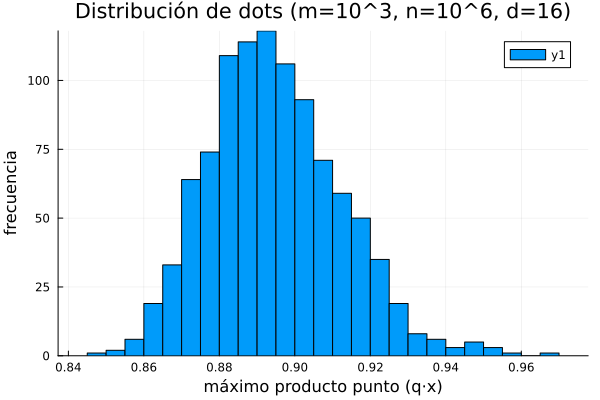

In [77]:
using Plots

histogram(dots,
    bins=50,
    title="Distribución de dots (m=10^3, n=10^6, d=16)",
    xlabel="máximo producto punto (q·x)",
    ylabel="frecuencia"
)


La gráfica muestra que los valores máximos del producto punto están alrededor de 0.88 y 0.9. Esto significa que, para cada vector de $Q$, se encontró algún vector en $X$ bastante parecido.

En general, la gráfica refleja que mientras más grande es el conjunto de comparación, mayor tiende a ser el máximo encontrado.


# Conclusiones

En este ejercicio se pudo ver claramente que la forma en que se resuelve un problema puede cambiar mucho los resultados en la práctica. Aunque A1 y A2 hacen básicamente lo mismo, su comportamiento es muy diferente cuando el tamaño de los datos aumenta.

A1 funciona bien cuando los tamaños son pequeños, pero cuando $m$ y $n$ crecen, la memoria que necesita se vuelve demasiado grande. Esto hace que deje de ser una opción viable en casos grandes. En cambio, A2 maneja mejor la memoria porque no guarda toda la información intermedia, lo que le permite trabajar con tamaños más grandes sin problemas.

También se observó que, al comparar cada vector contra un conjunto muy grande, siempre aparece alguno bastante parecido, lo cual explica por qué los valores máximos tienden a ser altos.

En general, el ejercicio deja claro que no solo importa que un algoritmo funcione, sino que sea eficiente y escalable. Elegir una mejor forma de organizar los cálculos puede hacer una gran diferencia cuando se trabaja con grandes volúmenes de datos.


# Referencias: 
- Cormen, Thomas H.; Leiserson, Charles E.; Rivest, Ronald L.; Stein, Clifford (2022). Introduction to Algorithms (2nd ed.). MIT Press.

